# Modeling - Dự đoán đơn hàng bị trả lại

## 1. Mục tiêu
* **Bài toán:** Dự đoán xác suất đơn hàng bị trả lại (`returned_label` = 1) ngay tại thời điểm khách hàng đặt hàng (`order placement`).
* **Đảm bảo độ tin cậy:** Triển khai quy trình chặt chẽ để chống rò rỉ dữ liệu (leakage), tiền xử lý tích hợp sâu trong Pipeline để fit lại độc lập trong từng fold thử nghiệm.
* **Tối ưu hóa:** Tinh chỉnh siêu tham số trên 3 expanding temporal folds, chọn ra mô hình tốt nhất (Champion) và khóa ngưỡng ra quyết định (Threshold) trên tập Validation trước khi đánh giá duy nhất một lần trên tập Test độc lập.

## 2. Quy trình thực hiện
* **Phase 0 - Setup:** Khai báo thư viện, kiểm tra phiên bản các dependency chính và thiết lập cấu trúc thư mục xuất kết quả.
* **Phase 1 - Modeling Contract:** Xác lập các ràng buộc thiết kế, kiểm tra tính hợp lệ của checklist Feature Engineering và đối chiếu với Leakage Gate để ngăn chặn feature bị cấm.
* **Phase 2 - Data Audit:** Kiểm tra chéo schema dữ liệu giữa các tập, xác nhận phân phối nhãn target, kiểm tra trùng lặp order và tính tuần tự thời gian (Train < Validation < Test).
* **Phase 3 - Preprocessing & Temporal Cross-Validation:** Xây dựng Pipeline tiền xử lý động (Imputer, Scaler, One-Hot, Quantile Bins) và chia 3 expanding temporal folds trên tập Train.
* **Phase 4 - Baseline Classification:** Huấn luyện mô hình dự đoán theo tỷ lệ nhãn (Dummy Classifier) và Logistic Regression với Core Features để làm mốc so sánh cơ sở.
* **Phase 5 - Initial Models:** Huấn luyện 3 mô hình ban đầu (Logistic Regression, Random Forest, LightGBM) kết hợp xử lý mất cân bằng lớp bằng các phương pháp gán trọng số (`class_weight`, `scale_pos_weight`).
* **Phase 6 - Metric & Threshold:** Vẽ biểu đồ PR và ROC Curves trên tập Validation; xác định ngưỡng phân loại tối ưu theo chính sách tối đa hóa F1-score và đảm bảo Recall tối thiểu 70%.
* **Phase 7 - Hyperparameter Tuning:** Thực hiện tối ưu hóa siêu tham số độc lập cho mỗi mô hình: `GridSearchCV` cho Logistic Regression, `RandomizedSearchCV` cho Random Forest và tối ưu hóa Bayesian qua `Optuna` cho LightGBM.
* **Phase 8 - So Sánh Tuned Models & Chọn Champion:** So sánh hiệu năng các cấu hình đã được tối ưu, đánh giá độ ổn định của metric (Stability) qua các fold thời gian để chọn ra mô hình Champion.
* **Phase 9 - Explainability & Error Analysis:** Phân tích lỗi dự đoán (Calibration Curve, Confusion Matrix) và giải thích mô hình thông qua trọng số thuộc tính hoặc SHAP values.
* **Phase 10 - Final Test:** Huấn luyện mô hình Champion trên toàn bộ dữ liệu Train + Validation, chạy suy diễn trên tập Test một lần duy nhất, xuất/lưu trữ model bundle và xác thực tính nhất quán khi tải lại mô hình.
* **Phase 11 - Readiness & Report:** Đối chiếu toàn bộ quy trình với Checklist vận hành và xuất báo cáo kết quả Modeling hoàn chỉnh.

 


---
## Phase 0 - Setup

### Mục tiêu
Thiết lập môi trường Modeling có thể tái lập, xác nhận đầy đủ dependency và chuẩn hóa nơi lưu toàn bộ artifact trước khi đọc dữ liệu hoặc huấn luyện model.

### Nhiệm vụ
- Import thư viện cho xử lý dữ liệu, preprocessing, temporal CV, ba thuật toán, tuning, metric, explainability và lưu model; đồng thời khóa `RANDOM_STATE`, `TARGET` và `PRIMARY_METRIC`.
- Kiểm tra khả năng import và ghi nhận version của `sklearn`, `lightgbm`, `optuna` và `shap` để phát hiện sớm dependency thiếu hoặc không tương thích.
- Xác định `PROJECT_ROOT`, khai báo các thư mục input/output và tạo sẵn nơi lưu bảng, hình, model, report và Optuna study.

In [1]:
# Phase 0.1 - Import thư viện
from pathlib import Path
import hashlib
import importlib
import json
import time
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap

from scipy import sparse
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TARGET = "returned_label"
PRIMARY_METRIC = "average_precision"


In [2]:
# Phase 0.2 - Kiểm tra dependency
dependency_rows = []
for package in ["sklearn", "lightgbm", "optuna", "shap"]:
    module = importlib.import_module(package)
    dependency_rows.append(
        {"package": package, "version": getattr(module, "__version__", "unknown"), "status": "OK"}
    )
dependency_audit = pd.DataFrame(dependency_rows)
display(dependency_audit)

,package,version,status
0,sklearn,1.7.2,OK
1,lightgbm,4.6.0,OK
2,optuna,4.9.0,OK
3,shap,0.49.1,OK


In [3]:
# Phase 0.3 - Khai báo đường dẫn
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "report_12_6_2026").exists():
    PROJECT_ROOT = Path.cwd().parent

FE_REPORT_DIR = PROJECT_ROOT / "report_12_6_2026"
MODEL_RUN_DIR = PROJECT_ROOT / "report_14_6_2026"
FE_TABLE_DIR = FE_REPORT_DIR / "fe_outputs" / "tables"
MODEL_OUTPUT_DIR = MODEL_RUN_DIR / "modeling_outputs"
MODEL_TABLE_DIR = MODEL_OUTPUT_DIR / "tables"
MODEL_FIGURE_DIR = MODEL_OUTPUT_DIR / "figures"
MODEL_DIR = MODEL_OUTPUT_DIR / "models"
MODEL_REPORT_DIR = MODEL_OUTPUT_DIR / "reports"
OPTUNA_DIR = MODEL_OUTPUT_DIR / "optuna"

for directory in [MODEL_TABLE_DIR, MODEL_FIGURE_DIR, MODEL_DIR, MODEL_REPORT_DIR, OPTUNA_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("FE input:", FE_TABLE_DIR)
print("Model output:", MODEL_OUTPUT_DIR)

FE input: b:\DA_VSF\customer_churn_PL\report_12_6_2026\fe_outputs\tables
Model output: b:\DA_VSF\customer_churn_PL\report_14_6_2026\modeling_outputs


### Kết luận Phase 0

- **Mục tiêu phase:** chuẩn bị môi trường, dependency và thư mục output cho toàn bộ Modeling.
- **Output chính:** các thư mục `modeling_outputs/tables`, `modeling_outputs/figures`, `modeling_outputs/models`, `modeling_outputs/optuna`.
- **Kết luận:** phase này chưa tạo metric model, nhưng đã thiết lập nền để mọi artifact sau đó ghi đúng một chuẩn đường dẫn. Việc kiểm tra dependency sớm giúp notebook fail sớm nếu thiếu thư viện thay vì lỗi giữa quá trình train/tuning.


---
## Phase 1 - Chốt Bài Toán Model

### Mục tiêu
Khóa contract của bài toán dự đoán tại thời điểm đặt hàng và xác nhận Modeling chỉ nhận dữ liệu, feature và chính sách đã được Feature Engineering phê duyệt.

### Nhiệm vụ
- Load Core/V1/Experimental feature lists, centralized leakage gate, selection report, preprocessing policy và FE readiness; xác định `BAN_LEAKAGE`, tạo SHA-256 input manifest, rồi lưu `modeling_contract.csv` và `modeling_input_manifest.csv`.

In [4]:
# Phase 1.1 - Load feature sets, leakage gate và modeling contract
feature_cols_core = pd.read_csv(FE_TABLE_DIR / "feature_cols_core.csv")["feature"].tolist()
feature_cols_v1 = pd.read_csv(FE_TABLE_DIR / "feature_cols_v1.csv")["feature"].tolist()
feature_cols_experimental = pd.read_csv(
    FE_TABLE_DIR / "feature_cols_experimental.csv"
)["feature"].tolist()
leakage_gate = pd.read_csv(FE_TABLE_DIR / "phase4_leakage_gate.csv")
selection_report = pd.read_csv(FE_TABLE_DIR / "phase4_feature_selection_report.csv")
preprocessing_policy_fe = pd.read_csv(FE_TABLE_DIR / "phase5_preprocessing_policy.csv")
fe_readiness = pd.read_csv(FE_TABLE_DIR / "fe_readiness_checklist.csv")
fe_readiness_passed = bool(fe_readiness["passed"].all())
banned_features = set(
    leakage_gate.loc[leakage_gate["action"].eq("BAN_LEAKAGE"), "column"]
)

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as source:
        for chunk in iter(lambda: source.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

modeling_input_files = [
    FE_TABLE_DIR / "feature_cols_v1.csv",
    FE_TABLE_DIR / "phase4_leakage_gate.csv",
    FE_TABLE_DIR / "phase5_preprocessing_policy.csv",
    FE_TABLE_DIR / "train_features_raw.csv",
    FE_TABLE_DIR / "valid_features_raw.csv",
    FE_TABLE_DIR / "test_features_raw.csv",
]
modeling_input_manifest = pd.DataFrame(
    [
        {
            "file": path.name,
            "size_bytes": path.stat().st_size,
            "modified_at": pd.Timestamp(path.stat().st_mtime, unit="s"),
            "sha256": sha256_file(path),
        }
        for path in modeling_input_files
    ]
)

modeling_contract = pd.DataFrame(
    [
        {"item": "problem_type", "value": "binary_classification"},
        {"item": "grain", "value": "one row per order_id"},
        {"item": "prediction_time", "value": "order placement"},
        {"item": "target", "value": TARGET},
        {"item": "positive_class", "value": "returned = 1"},
        {"item": "label_source", "value": "orders.order_status"},
        {"item": "feature_availability", "value": "available at or before order_date"},
        {"item": "primary_metric", "value": "PR-AUC / average_precision"},
        {"item": "main_feature_count", "value": len(feature_cols_v1)},
        {"item": "fe_readiness_passed", "value": fe_readiness_passed},
        {"item": "test_policy", "value": "use once after champion is locked"},
    ]
)
modeling_contract.to_csv(MODEL_TABLE_DIR / "modeling_contract.csv", index=False)
modeling_input_manifest.to_csv(MODEL_TABLE_DIR / "modeling_input_manifest.csv", index=False)
display(modeling_contract)


,item,value
0,problem_type,binary_classification
1,grain,one row per order_id
2,prediction_time,order placement
3,target,returned_label
4,positive_class,returned = 1
5,label_source,orders.order_status
6,feature_availability,available at or before order_date
7,primary_metric,PR-AUC / average_precision
8,main_feature_count,28
9,fe_readiness_passed,True


### Kết luận Phase 1

- **Contract bài toán:** binary classification, grain là **một dòng trên mỗi `order_id`**, target là `returned_label`, positive class là **returned = 1**.
- **Nguồn label:** `orders.order_status`; chỉ dùng feature available at/before `order_date`.
- **Metric chính:** **PR-AUC / average precision** vì positive class mất cân bằng.
- **Feature chính:** `feature_cols_v1.csv` có **28 feature**.
- **Input manifest:** ghi nhận đủ 6 artifact đầu vào quan trọng gồm feature list, leakage gate, preprocessing policy và 3 raw split train/validation/test, có size và sha256 để truy vết.
- **Kết luận:** Modeling không tự chọn lại feature từ dữ liệu gốc; toàn bộ bước sau bám theo contract và feature set đã khóa từ FE.


---
## Phase 2 - Load & Audit Dữ Liệu Modeling

### Mục tiêu
Xác minh ba raw temporal split đúng grain, schema, target, thứ tự thời gian và leakage contract trước khi bất kỳ model nào được fit.

### Nhiệm vụ
- Load `train_features_raw.csv`, `valid_features_raw.csv` và `test_features_raw.csv`, parse `order_date`, rồi ánh xạ thành các outer train/validation/test frame dùng xuyên suốt notebook.
- Audit exact schema, binary target, số lượng order/label, overlap, temporal order và banned feature trong feature sets/raw splits; lưu `phase2_data_audit.csv` và dừng pipeline nếu có kiểm tra thất bại.
- Thống kê missing theo từng split, kiểm tra phân phối `returned_label`, lưu `phase2_missing_audit.csv` và vẽ `phase2_label_distribution.png` để nhận diện drift hoặc bất thường đầu vào.

In [5]:
# Phase 2.1 - Load raw temporal splits từ Feature Engineering
train_df = pd.read_csv(FE_TABLE_DIR / "train_features_raw.csv", parse_dates=["order_date"])
valid_df = pd.read_csv(FE_TABLE_DIR / "valid_features_raw.csv", parse_dates=["order_date"])
test_df = pd.read_csv(FE_TABLE_DIR / "test_features_raw.csv", parse_dates=["order_date"])

split_frames = {"train": train_df, "validation": valid_df, "test": test_df}
split_overview = pd.DataFrame(
    [
        {
            "split": name,
            "n_rows": len(frame),
            "n_orders": frame["order_id"].nunique(),
            "start_date": frame["order_date"].min(),
            "end_date": frame["order_date"].max(),
            "return_rate": frame[TARGET].mean(),
        }
        for name, frame in split_frames.items()
    ]
)
display(split_overview)

,split,n_rows,n_orders,start_date,end_date,return_rate
0,train,386907,386907,2012-07-04,2018-04-27,0.065370
1,validation,82906,82906,2018-04-28,2020-03-27,0.063723
2,test,83045,83045,2020-03-28,2022-12-31,0.067036


In [6]:
# Phase 2.2 - Audit schema, target, overlap và centralized leakage gate
expected_columns = set(["order_id", "order_date", "data_split", TARGET] + feature_cols_v1)
feature_sets = set(feature_cols_core + feature_cols_v1 + feature_cols_experimental)

overlap_count = (
    len(set(train_df["order_id"]) & set(valid_df["order_id"]))
    + len(set(train_df["order_id"]) & set(test_df["order_id"]))
    + len(set(valid_df["order_id"]) & set(test_df["order_id"]))
)

audit_rows = [
    {
        "check": "fe_readiness_passed",
        "passed": fe_readiness_passed,
        "detail": int(fe_readiness["passed"].sum()),
    },
    {
        "check": "feature_list_nonempty_and_unique",
        "passed": len(feature_cols_v1) > 1 and len(feature_cols_v1) == len(set(feature_cols_v1)),
        "detail": len(feature_cols_v1),
    },
    {
        "check": "all_splits_match_exact_schema",
        "passed": all(set(frame.columns) == expected_columns for frame in split_frames.values()),
        "detail": sorted(expected_columns),
    },
    {
        "check": "target_is_binary",
        "passed": all(set(frame[TARGET].dropna().unique()) <= {0, 1} for frame in split_frames.values()),
        "detail": "0/1",
    },
    {
        "check": "no_order_overlap",
        "passed": overlap_count == 0,
        "detail": overlap_count,
    },
    {
        "check": "temporal_order",
        "passed": train_df["order_date"].max() < valid_df["order_date"].min()
        and valid_df["order_date"].max() < test_df["order_date"].min(),
        "detail": "train < validation < test",
    },
    {
        "check": "no_banned_feature_in_feature_sets",
        "passed": not bool(feature_sets & banned_features),
        "detail": sorted(feature_sets & banned_features),
    },
    {
        "check": "no_banned_feature_in_raw_splits",
        "passed": all(not bool(set(frame.columns) & banned_features) for frame in split_frames.values()),
        "detail": sorted(banned_features),
    },
    {
        "check": "banned_features_have_audit_reason",
        "passed": leakage_gate.loc[leakage_gate["action"].eq("BAN_LEAKAGE"), "reason"].notna().all(),
        "detail": len(banned_features),
    },
    {
        "check": "expected_order_and_label_counts",
        "passed": sum(len(frame) for frame in split_frames.values()) == 552858
        and sum(int(frame[TARGET].eq(0).sum()) for frame in split_frames.values()) == 516716
        and sum(int(frame[TARGET].eq(1).sum()) for frame in split_frames.values()) == 36142,
        "detail": "552858 rows; 516716 delivered; 36142 returned",
    },
    {
        "check": "split_labels_match_frame_names",
        "passed": all(frame["data_split"].eq(name).all() for name, frame in split_frames.items()),
        "detail": "train/validation/test",
    },
]
phase2_audit = pd.DataFrame(audit_rows)
phase2_audit.to_csv(MODEL_TABLE_DIR / "phase2_data_audit.csv", index=False)
display(phase2_audit)

if not phase2_audit["passed"].all():
    raise RuntimeError("Phase 2 modeling audit failed.")


,check,passed,detail
0,fe_readiness_passed,True,21
1,feature_list_nonempty_and_unique,True,28
2,all_splits_match_exact_schema,True,"[age_group, category_Casual, category_GenZ, ca..."
3,target_is_binary,True,0/1
4,no_order_overlap,True,0
5,temporal_order,True,train < validation < test
6,no_banned_feature_in_feature_sets,True,[]
7,no_banned_feature_in_raw_splits,True,"[high_risk_product_count, max_product_return_r..."
8,banned_features_have_audit_reason,True,3
9,expected_order_and_label_counts,True,552858 rows; 516716 delivered; 36142 returned


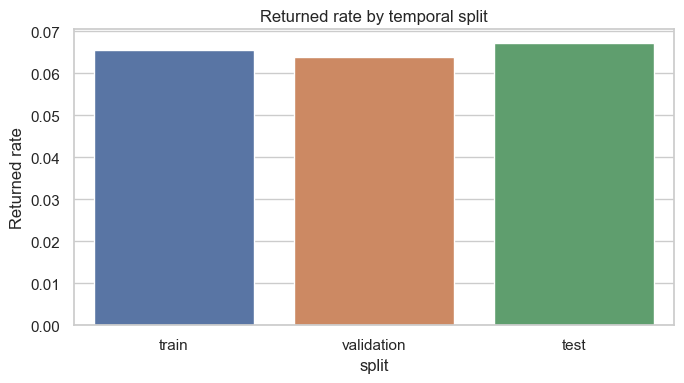

In [7]:
# Phase 2.3 - Missing và phân phối target
missing_rows = []
for split_name, frame in split_frames.items():
    for feature in feature_cols_v1:
        missing_rows.append(
            {
                "split": split_name,
                "feature": feature,
                "missing_count": int(frame[feature].isna().sum()),
                "missing_rate": float(frame[feature].isna().mean()),
            }
        )
missing_audit = pd.DataFrame(missing_rows)
missing_audit.to_csv(MODEL_TABLE_DIR / "phase2_missing_audit.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=split_overview, x="split", y="return_rate", hue="split", legend=False, ax=ax)
ax.set_title("Returned rate by temporal split")
ax.set_ylabel("Returned rate")
plt.tight_layout()
fig.savefig(MODEL_FIGURE_DIR / "phase2_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Kết luận Phase 2

- **Data contract:** `phase2_data_audit.csv` pass **11/11 checks**.
- **Số dòng có nhãn:** **552,858 orders**, gồm **516,716 delivered** và **36,142 returned**.
- **Schema/split:** train, validation và test có schema giống nhau; không có overlap order; thứ tự thời gian đúng.
- **Leakage:** banned features không xuất hiện trong feature set hoặc raw split.
- **Missing:** `phase2_missing_audit.csv` cho thấy `missing_count` tối đa bằng **0** và `missing_rate` tối đa bằng **0.0** trên các feature modeling.
- **Kết luận:** dữ liệu đủ sạch để train model; class imbalance rõ nên các phase sau cần ưu tiên PR-AUC, recall/precision và threshold review thay vì accuracy.


---
## Phase 3 - Preprocessing & Temporal Cross-Validation

### Mục tiêu
xây dựng preprocessing chống leakage và cơ chế temporal cross-validation chỉ dùng outer train, làm nền tảng thống nhất cho baseline, tuning và đánh giá model.

### Nhiệm vụ
- Phân loại V1 features thành numeric/categorical/binary; định nghĩa `ColumnTransformer` gồm imputation, scaling, one-hot và `KBinsDiscretizer` cho `payment_value`, bảo đảm transformer được fit lại trong từng model/CV fold; lưu `preprocessing_policy.csv`.
- Tạo ba expanding temporal folds hoàn toàn bên trong outer train, kiểm tra validation luôn xảy ra sau training và lưu biên thời gian/số dòng vào `phase3_temporal_folds.csv`.
- Định nghĩa các hàm dùng chung để tính PR-AUC, ROC-AUC, precision, recall, F1, balanced accuracy và sinh probability/prediction nhất quán cho mọi model.

In [8]:
# Phase 3.1 - Preprocessing policy được fit lại trong từng model/CV fold
binary_features = [
    feature for feature in feature_cols_v1
    if pd.api.types.is_numeric_dtype(train_df[feature])
    and set(train_df[feature].dropna().unique()) <= {0, 1}
]
numeric_features = [
    feature for feature in feature_cols_v1
    if pd.api.types.is_numeric_dtype(train_df[feature]) and feature not in binary_features
]
categorical_features = [
    feature for feature in feature_cols_v1
    if feature not in numeric_features and feature not in binary_features
]

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

def make_preprocessor(features):
    numeric = [f for f in features if f in numeric_features]
    categorical = [f for f in features if f in categorical_features]
    binary = [f for f in features if f in binary_features]
    transformers = []
    if numeric:
        transformers.append(
            (
                "numeric",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric,
            )
        )
    if categorical:
        transformers.append(
            (
                "categorical",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", make_one_hot_encoder()),
                    ]
                ),
                categorical,
            )
        )
    if binary:
        transformers.append(("binary", SimpleImputer(strategy="most_frequent"), binary))
    if "payment_value" in features:
        transformers.append(
            (
                "payment_quantile",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        (
                            "quantile_bins",
                            KBinsDiscretizer(
                                n_bins=4,
                                encode="onehot",
                                strategy="quantile",
                                subsample=None,
                            ),
                        ),
                    ]
                ),
                ["payment_value"],
            )
        )
    return ColumnTransformer(transformers, remainder="drop")

preprocessing_policy = pd.DataFrame(
    [
        {"data_type": "numeric", "features": ", ".join(numeric_features), "steps": "median -> standard scaler"},
        {"data_type": "categorical", "features": ", ".join(categorical_features), "steps": "most frequent -> one hot"},
        {"data_type": "binary", "features": ", ".join(binary_features), "steps": "most frequent -> passthrough"},
        {
            "data_type": "derived_quantile",
            "features": "payment_value" if "payment_value" in feature_cols_v1 else "",
            "steps": "median -> 4 quantile bins -> one hot; fit inside each model/CV fold",
        },
    ]
)
preprocessing_policy.to_csv(MODEL_TABLE_DIR / "preprocessing_policy.csv", index=False)
display(preprocessing_policy)


,data_type,features,steps
0,numeric,"customer_tenure_days, total_quantity, unique_p...",median -> standard scaler
1,categorical,"payment_method, device_type, order_source, ten...",most frequent -> one hot
2,binary,"is_discounted, category_Casual, category_GenZ,...",most frequent -> passthrough
3,derived_quantile,payment_value,median -> 4 quantile bins -> one hot; fit insi...


In [9]:
# Phase 3.2 - Tạo 3 expanding temporal folds chỉ trong train
train_sorted = train_df.sort_values(["order_date", "order_id"]).reset_index(drop=True)
unique_dates = np.array(sorted(train_sorted["order_date"].unique()))
fold_fractions = [(0.55, 0.70), (0.70, 0.85), (0.85, 1.00)]
temporal_cv = []
fold_audit_rows = []

for fold, (train_fraction, valid_fraction) in enumerate(fold_fractions, start=1):
    train_end = pd.Timestamp(unique_dates[min(int(len(unique_dates) * train_fraction), len(unique_dates) - 1)])
    valid_end = pd.Timestamp(unique_dates[min(int(len(unique_dates) * valid_fraction), len(unique_dates) - 1)])
    train_index = np.flatnonzero((train_sorted["order_date"] < train_end).to_numpy())
    if fold == len(fold_fractions):
        valid_mask = train_sorted["order_date"].ge(train_end) & train_sorted["order_date"].le(valid_end)
    else:
        valid_mask = train_sorted["order_date"].ge(train_end) & train_sorted["order_date"].lt(valid_end)
    valid_index = np.flatnonzero(valid_mask.to_numpy())
    temporal_cv.append((train_index, valid_index))
    fold_audit_rows.append(
        {
            "fold": fold,
            "train_rows": len(train_index),
            "validation_rows": len(valid_index),
            "train_end": train_sorted.iloc[train_index]["order_date"].max(),
            "validation_start": train_sorted.iloc[valid_index]["order_date"].min(),
            "validation_end": train_sorted.iloc[valid_index]["order_date"].max(),
            "train_return_rate": train_sorted.iloc[train_index][TARGET].mean(),
            "validation_return_rate": train_sorted.iloc[valid_index][TARGET].mean(),
        }
    )

temporal_fold_audit = pd.DataFrame(fold_audit_rows)
temporal_fold_audit.to_csv(MODEL_TABLE_DIR / "phase3_temporal_folds.csv", index=False)
display(temporal_fold_audit)

,fold,train_rows,validation_rows,train_end,validation_start,validation_end,train_return_rate,validation_return_rate
0,1,215042,63195,2015-09-14,2015-09-15,2016-07-28,0.065364,0.066239
1,2,278237,57325,2016-07-28,2016-07-29,2017-06-12,0.065563,0.063218
2,3,335562,51345,2017-06-12,2017-06-13,2018-04-27,0.065162,0.066725


In [10]:
# Phase 3.3 - Hàm metric và prediction dùng chung
def classification_metrics(y_true, probability, threshold=0.5):
    prediction = (np.asarray(probability) >= threshold).astype(int)
    return {
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "threshold": threshold,
    }

def fit_and_score(model_name, model, features, train_frame, eval_frame):
    started = time.time()
    model.fit(train_frame[features], train_frame[TARGET])
    probability = model.predict_proba(eval_frame[features])[:, 1]
    metrics = classification_metrics(eval_frame[TARGET], probability, threshold=0.5)
    metrics.update(
        {
            "model": model_name,
            "n_features": len(features),
            "fit_seconds": time.time() - started,
        }
    )
    return model, probability, metrics

### Kết luận Phase 3

- **Preprocessing numeric:** 6 numeric features dùng **median -> standard scaler**.
- **Preprocessing categorical:** 6 categorical features dùng **most frequent -> one-hot**.
- **Preprocessing binary:** 16 binary features dùng **most frequent -> passthrough**.
- **Derived feature:** `payment_value` có thêm **4 quantile bins**, fit bên trong từng model/CV fold.
- **Temporal CV:** 3 expanding folds chỉ nằm trong train:
  - Fold 1: **215,042 train / 63,195 validation**.
  - Fold 2: **278,237 train / 57,325 validation**.
  - Fold 3: **335,562 train / 51,345 validation**.
- **Kết luận:** preprocessing và CV được thiết kế đúng để tránh học thông tin từ validation/test; các fold có return rate gần nhau nên phù hợp để so sánh stability theo thời gian.


---
## Phase 4 - Baseline Classification

### Mục tiêu
Thiết lập hai mốc hiệu năng tối thiểu trên outer validation để các model phức tạp hơn phải chứng minh giá trị bổ sung thực sự.

### Nhiệm vụ
- Fit `DummyClassifier(strategy="prior")` trên outer train và đánh giá outer validation để tạo mốc không sử dụng tín hiệu feature.
- Fit Logistic Regression với Core features trong preprocessing pipeline, so sánh với Dummy baseline và lưu kết quả vào `phase4_baseline_metrics.csv`.

In [11]:
# Phase 4.1 - Dummy baseline
dummy_model = DummyClassifier(strategy="prior")
dummy_model.fit(train_df[feature_cols_core], train_df[TARGET])
dummy_valid_probability = dummy_model.predict_proba(valid_df[feature_cols_core])[:, 1]
dummy_metrics = classification_metrics(valid_df[TARGET], dummy_valid_probability)
dummy_metrics.update({"model": "Dummy prior", "n_features": len(feature_cols_core), "fit_seconds": 0.0})

In [12]:
# Phase 4.2 - Logistic Regression với core features
core_logistic = Pipeline(
    [
        ("preprocessor", make_preprocessor(feature_cols_core)),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                solver="liblinear",
                max_iter=300,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
core_logistic, core_valid_probability, core_metrics = fit_and_score(
    "Core Logistic", core_logistic, feature_cols_core, train_df, valid_df
)

baseline_metrics = pd.DataFrame([dummy_metrics, core_metrics])
baseline_metrics.to_csv(MODEL_TABLE_DIR / "phase4_baseline_metrics.csv", index=False)
display(baseline_metrics)

,pr_auc,roc_auc,precision,recall,f1,balanced_accuracy,threshold,model,n_features,fit_seconds
0,0.063723,0.500000,0.000000,0.000000,0.000000,0.500000,0.5,Dummy prior,2,0.000000
1,0.076408,0.553883,0.109254,0.237554,0.149672,0.552869,0.5,Core Logistic,2,0.405344


### Kết luận Phase 4

- **Dummy prior:** validation **PR-AUC = 0.063723**, **ROC-AUC = 0.500000**.
- **Core Logistic:** dùng 2 core features (`is_cod`, `payment_method`) đạt:
  - **PR-AUC = 0.076408**
  - **ROC-AUC = 0.553883**
  - **Precision = 0.109254**
  - **Recall = 0.237554**
  - **F1 = 0.149672**
- **Kết luận:** dữ liệu có tín hiệu dự đoán thật so với Dummy, nhưng lift ban đầu còn mỏng. Phase sau cần kiểm tra liệu 28 V1 features và model phi tuyến có cải thiện đáng kể hay không.


---
## Phase 5 - Train Model first

### Mục tiêu
Đánh giá các model với cấu hình ban đầu trên cùng V1 feature set và outer validation trước khi đầu tư chi phí tuning.

### Nhiệm vụ
- Khai báo Logistic Regression, Random Forest và LightGBM với chiến lược xử lý mất cân bằng phù hợp, tất cả được ghép với preprocessing pipeline.
- Fit từng pipeline trên outer train, dự đoán outer validation, tính bộ metric thống nhất và lưu `phase5_initial_model_metrics.csv`.
- Gom validation probabilities theo `order_id`, lưu `phase5_validation_predictions.csv` và vẽ `phase5_model_comparison.png` để so sánh hiệu năng ban đầu.

In [13]:
# Phase 5.1 - Khai báo ba model ban đầu
positive_count = train_df[TARGET].sum()
negative_count = len(train_df) - positive_count
scale_pos_weight = negative_count / positive_count

initial_models = {
    "Logistic Regression": Pipeline(
        [
            ("preprocessor", make_preprocessor(feature_cols_v1)),
            (
                "classifier",
                LogisticRegression(
                    class_weight="balanced",
                    solver="liblinear",
                    max_iter=300,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        [
            ("preprocessor", make_preprocessor(feature_cols_v1)),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=250,
                    max_depth=16,
                    min_samples_leaf=5,
                    max_features="sqrt",
                    class_weight="balanced_subsample",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "LightGBM": Pipeline(
        [
            ("preprocessor", make_preprocessor(feature_cols_v1)),
            (
                "classifier",
                lgb.LGBMClassifier(
                    n_estimators=500,
                    learning_rate=0.05,
                    num_leaves=31,
                    max_depth=-1,
                    scale_pos_weight=scale_pos_weight,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbosity=-1,
                ),
            ),
        ]
    ),
}

In [14]:
# Phase 5.2 - Train và đánh giá validation
initial_fitted_models = {}
initial_valid_probabilities = {}
initial_metric_rows = []

for model_name, model in initial_models.items():
    fitted_model, probability, metrics = fit_and_score(
        model_name, model, feature_cols_v1, train_df, valid_df
    )
    initial_fitted_models[model_name] = fitted_model
    initial_valid_probabilities[model_name] = probability
    initial_metric_rows.append(metrics)

initial_metrics = pd.DataFrame(initial_metric_rows).sort_values("pr_auc", ascending=False)
initial_metrics.to_csv(MODEL_TABLE_DIR / "phase5_initial_model_metrics.csv", index=False)
display(initial_metrics)

b:\DA_VSF\customer_churn_PL\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,pr_auc,roc_auc,precision,recall,f1,balanced_accuracy,threshold,model,n_features,fit_seconds
0,0.080873,0.550431,0.108468,0.239069,0.149229,0.552666,0.5,Logistic Regression,28,3.905181
1,0.080320,0.547571,0.107898,0.154647,0.127110,0.533812,0.5,Random Forest,28,43.168180
2,0.078067,0.538708,0.088053,0.249858,0.130216,0.536869,0.5,LightGBM,28,3.447134


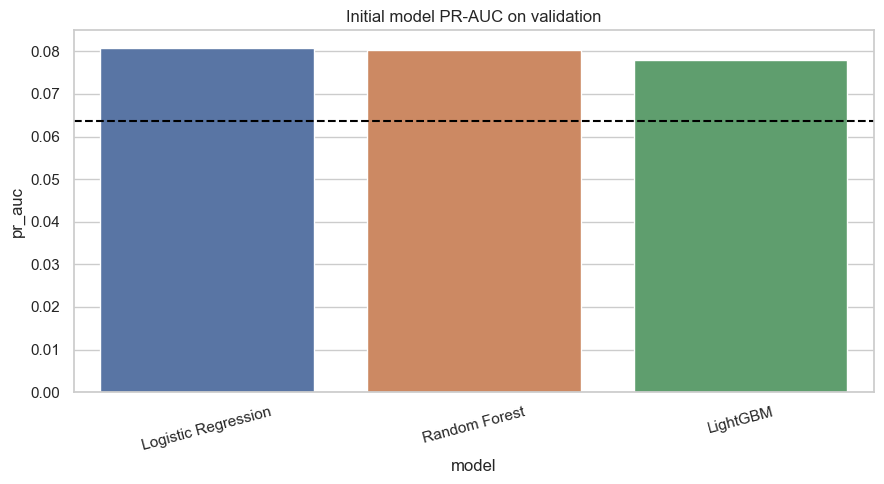

In [15]:
# Phase 5.3 - Lưu validation probabilities và biểu đồ so sánh
validation_predictions = valid_df[["order_id", "order_date", TARGET]].copy()
for model_name, probability in initial_valid_probabilities.items():
    validation_predictions[f"{model_name}_probability"] = probability
validation_predictions.to_csv(
    MODEL_TABLE_DIR / "phase5_validation_predictions.csv", index=False
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=initial_metrics, x="model", y="pr_auc", hue="model", legend=False, ax=ax)
ax.axhline(valid_df[TARGET].mean(), color="black", linestyle="--", label="positive baseline")
ax.set_title("Initial model PR-AUC on validation")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
fig.savefig(MODEL_FIGURE_DIR / "phase5_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Kết luận Phase 5

- **Logistic Regression initial:** validation **PR-AUC = 0.080873**, **ROC-AUC = 0.550431**.
- **Random Forest initial:** validation **PR-AUC = 0.080320**, **ROC-AUC = 0.547571**.
- **LightGBM initial:** validation **PR-AUC = 0.078067**, **ROC-AUC = 0.538708**.
- **Output chính:** `phase5_initial_model_metrics.csv`, `phase5_validation_predictions.csv`, `phase5_model_comparison.png`.
- **Kết luận:** 28 V1 features cải thiện so với core baseline, nhưng ba model vẫn chỉ tạo lift vừa phải. Logistic Regression đang dẫn nhẹ ở initial run, còn model phức tạp chưa cho thấy ưu thế rõ trước tuning.


---
## Phase 6 - Metric & Threshold

### Mục tiêu
Phân tích trade-off precision/recall trên outer validation và xác định các threshold ứng viên mà không sử dụng final test.

### Nhiệm vụ
- Từ validation probabilities của từng model, tính threshold tối đa F1 và threshold đạt recall tối thiểu 70%; lưu toàn bộ metric theo threshold và lựa chọn vào `phase6_threshold_metrics.csv` cùng `phase6_selected_thresholds.csv`.
- Vẽ Precision-Recall và ROC curves cho các model trên outer validation, lưu `phase6_pr_roc_curves.png` để hỗ trợ diễn giải khả năng phân biệt và vận hành.

In [16]:
# Phase 6.1 - Tính threshold tối đa F1 và threshold đạt recall >= 70%
def threshold_table(y_true, probability):
    precision, recall, thresholds = precision_recall_curve(y_true, probability)
    rows = []
    for p, r, threshold in zip(precision[:-1], recall[:-1], thresholds):
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        rows.append({"threshold": threshold, "precision": p, "recall": r, "f1": f1})
    return pd.DataFrame(rows)

threshold_rows = []
selected_threshold_rows = []
for model_name, probability in initial_valid_probabilities.items():
    table = threshold_table(valid_df[TARGET], probability)
    table["model"] = model_name
    threshold_rows.append(table)

    best_f1_row = table.loc[table["f1"].idxmax()]
    recall_candidates = table.loc[table["recall"].ge(0.70)]
    recall_row = (
        recall_candidates.sort_values(["precision", "threshold"], ascending=False).iloc[0]
        if not recall_candidates.empty
        else table.loc[table["recall"].idxmax()]
    )
    selected_threshold_rows.extend(
        [
            {
                "model": model_name,
                "policy": "max_f1",
                "threshold": best_f1_row["threshold"],
                "precision": best_f1_row["precision"],
                "recall": best_f1_row["recall"],
                "f1": best_f1_row["f1"],
            },
            {
                "model": model_name,
                "policy": "recall_at_least_70pct",
                "threshold": recall_row["threshold"],
                "precision": recall_row["precision"],
                "recall": recall_row["recall"],
                "f1": recall_row["f1"],
            },
        ]
    )

threshold_metrics = pd.concat(threshold_rows, ignore_index=True)
selected_thresholds = pd.DataFrame(selected_threshold_rows)
threshold_metrics.to_csv(MODEL_TABLE_DIR / "phase6_threshold_metrics.csv", index=False)
selected_thresholds.to_csv(MODEL_TABLE_DIR / "phase6_selected_thresholds.csv", index=False)
display(selected_thresholds)

,model,policy,threshold,precision,recall,f1
0,Logistic Regression,max_f1,0.619667,0.109873,0.235094,0.149756
1,Logistic Regression,recall_at_least_70pct,0.458162,0.066494,0.700170,0.121454
2,Random Forest,max_f1,0.465958,0.106354,0.208783,0.140922
3,Random Forest,recall_at_least_70pct,0.359948,0.067481,0.703010,0.123141
4,LightGBM,max_f1,0.513171,0.091717,0.230551,0.131229
5,LightGBM,recall_at_least_70pct,0.342978,0.066534,0.700738,0.121528


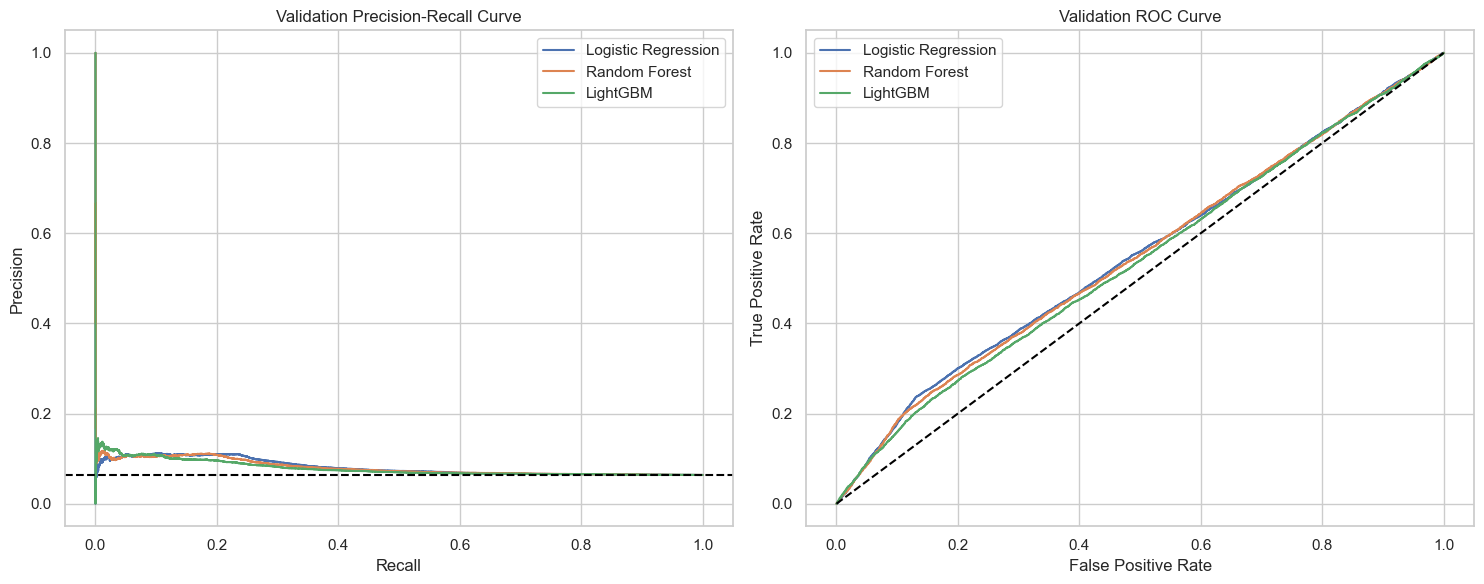

In [17]:
# Phase 6.2 - Precision-Recall và ROC curves
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for model_name, probability in initial_valid_probabilities.items():
    precision, recall, _ = precision_recall_curve(valid_df[TARGET], probability)
    fpr, tpr, _ = roc_curve(valid_df[TARGET], probability)
    axes[0].plot(recall, precision, label=model_name)
    axes[1].plot(fpr, tpr, label=model_name)

axes[0].axhline(valid_df[TARGET].mean(), color="black", linestyle="--")
axes[0].set_title("Validation Precision-Recall Curve")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[1].plot([0, 1], [0, 1], color="black", linestyle="--")
axes[1].set_title("Validation ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
for ax in axes:
    ax.legend()
plt.tight_layout()
fig.savefig(MODEL_FIGURE_DIR / "phase6_pr_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### Kết luận Phase 6

- **Threshold metrics:** `phase6_threshold_metrics.csv` có **246,770 dòng metric** cho 3 model.
- **Max F1 policy:**
  - Logistic Regression: threshold **0.619667**, precision **0.109873**, recall **0.235094**, F1 **0.149756**.
  - Random Forest: threshold **0.465958**, precision **0.106354**, recall **0.208783**, F1 **0.140922**.
  - LightGBM initial: threshold **0.513171**, precision **0.091717**, recall **0.230551**, F1 **0.131229**.
- **Recall >= 70% policy:** đạt recall mục tiêu nhưng precision giảm về khoảng **0.0665-0.0675**.
- **Kết luận:** nếu business ép recall rất cao thì false positive sẽ nhiều. Với baseline V1, threshold theo max F1 hợp lý hơn để cân bằng precision/recall.


---
## Phase 7 - Hyperparameter Tuning

### Mục tiêu
Tối ưu ba họ model bằng PR-AUC trên temporal CV của outer train, đồng thời giữ preprocessing và mọi thống kê học được hoàn toàn bên trong từng fold.

### Nhiệm vụ
- Chạy `GridSearchCV` cho Logistic Regression bằng ba temporal folds, lưu toàn bộ kết quả, best params và pipeline tốt nhất vào `phase7_logistic_grid_results.csv`, `phase7_logistic_best_params.json` và `logistic_tuned.joblib`.
- Chạy `RandomizedSearchCV` cho Random Forest với 5 cấu hình trên cùng temporal CV, lưu `phase7_rf_random_results.csv`, `phase7_rf_best_params.json` và `random_forest_tuned.joblib`.
- Fit riêng preprocessor trên train portion của từng Optuna fold và cache transformed train/validation matrices để LightGBM tuning không dùng transformer học từ toàn bộ outer train.
- Chạy 15 Optuna trials cho LightGBM unweighted với `average_precision` làm objective; early stopping khóa số cây hiệu dụng, sau đó lưu persistent study, trial history và best params vào `lightgbm_study_v2.db`, `phase7_optuna_trials.csv` và `phase7_lgbm_best_params.json`.

In [ ]:
# Phase 7.1 - GridSearchCV cho Logistic Regression
logistic_search_pipeline = Pipeline(
    [
        ("preprocessor", make_preprocessor(feature_cols_v1)),
        (
            "classifier",
            LogisticRegression(
                solver="liblinear",
                max_iter=400,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
# classifier_c điều chỉnh mức độ regularization.
# classifier__penalty xử dụng phạt các hệ số lớn khiến mô hình ổn đink
# cân bằng duwxx liệu : tăng trọng số cho các nhãn chiếm ít
logistic_param_grid = {
    "classifier__C": [0.1, 1.0], 
    "classifier__penalty": ["l2"],
    "classifier__class_weight": ["balanced"],
}
logistic_grid = GridSearchCV(
    logistic_search_pipeline,
    logistic_param_grid,
    scoring={"pr_auc": PRIMARY_METRIC, "roc_auc": "roc_auc"},
    cv=temporal_cv,
    n_jobs=2, # chỉnh sửa 
    refit="pr_auc",
    return_train_score=False,
    verbose=1,
)
logistic_grid.fit(train_sorted[feature_cols_v1], train_sorted[TARGET])
logistic_grid_results = pd.DataFrame(logistic_grid.cv_results_).sort_values("rank_test_pr_auc")
logistic_grid_results.to_csv(MODEL_TABLE_DIR / "phase7_logistic_grid_results.csv", index=False)
(MODEL_TABLE_DIR / "phase7_logistic_best_params.json").write_text(
    json.dumps(logistic_grid.best_params_, indent=2), encoding="utf-8"
)
joblib.dump(logistic_grid.best_estimator_, MODEL_DIR / "logistic_tuned.joblib")
print("Best Logistic:", logistic_grid.best_score_, logistic_grid.best_params_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best Logistic: 0.0863497263685478 {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}


In [19]:
# Phase 7.2 - RandomizedSearchCV cho Random Forest
rf_search_pipeline = Pipeline(
    [
        ("preprocessor", make_preprocessor(feature_cols_v1)),
        (
            "classifier",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=2,
            ),
        ),
    ]
)
rf_param_distributions = {
    "classifier__n_estimators": [100, 250],
    "classifier__max_depth": [8, 12],
    "classifier__min_samples_split": [5, 10],
    "classifier__min_samples_leaf": [2, 5],
    "classifier__max_features": ["sqrt"],
    "classifier__class_weight": ["balanced_subsample"],
}
rf_random = RandomizedSearchCV(
    rf_search_pipeline,
    rf_param_distributions,
    n_iter=5,
    scoring={"pr_auc": PRIMARY_METRIC, "roc_auc": "roc_auc"},
    cv=temporal_cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit="pr_auc",
    return_train_score=False,
    verbose=1,
)
rf_random.fit(train_sorted[feature_cols_v1], train_sorted[TARGET])
rf_random_results = pd.DataFrame(rf_random.cv_results_).sort_values("rank_test_pr_auc")
rf_random_results.to_csv(MODEL_TABLE_DIR / "phase7_rf_random_results.csv", index=False)
(MODEL_TABLE_DIR / "phase7_rf_best_params.json").write_text(
    json.dumps(rf_random.best_params_, indent=2), encoding="utf-8"
)
joblib.dump(rf_random.best_estimator_, MODEL_DIR / "random_forest_tuned.joblib")
print("Best Random Forest:", rf_random.best_score_, rf_random.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Random Forest: 0.08466072678868958 {'classifier__n_estimators': 250, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 8, 'classifier__class_weight': 'balanced_subsample'}


In [20]:
# Phase 7.3 - Cache preprocessing cho 3 Optuna folds
lgb_fold_cache = []
for fold_number, (train_index, valid_index) in enumerate(temporal_cv, start=1):
    fold_train = train_sorted.iloc[train_index]
    fold_valid = train_sorted.iloc[valid_index]
    fold_preprocessor = make_preprocessor(feature_cols_v1)
    X_fold_train = fold_preprocessor.fit_transform(fold_train[feature_cols_v1])
    X_fold_valid = fold_preprocessor.transform(fold_valid[feature_cols_v1])
    y_fold_train = fold_train[TARGET].to_numpy()
    y_fold_valid = fold_valid[TARGET].to_numpy()
    lgb_fold_cache.append(
        (
            X_fold_train,
            y_fold_train,
            X_fold_valid,
            y_fold_valid,
        )
    )
print("Cached LightGBM folds:", len(lgb_fold_cache))

Cached LightGBM folds: 3


In [21]:
# Phase 7.4 - Optuna 15 trials cho LightGBM
def lgbm_objective(trial):
    max_depth = trial.suggest_int("max_depth", 3, 6)
    max_leaves = min(31, 2 ** max_depth - 1)
    params = {
        "n_estimators": 500,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 7, max_leaves),
        "max_depth": max_depth,
        "min_child_samples": trial.suggest_int("min_child_samples", 50, 300),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "max_bin": trial.suggest_categorical("max_bin", [31, 63, 127]),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "subsample_freq": 1,
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.1),
        "metric": "average_precision",
        "random_state": RANDOM_STATE,
        "n_jobs": 2,
        "verbosity": -1,
    }
    fold_scores = []
    best_iterations = []
    for X_fold_train, y_fold_train, X_fold_valid, y_fold_valid in lgb_fold_cache:
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_fold_train,
            y_fold_train,
            eval_set=[(X_fold_valid, y_fold_valid)],
            eval_metric="average_precision",
            callbacks=[lgb.early_stopping(30, first_metric_only=True, verbose=False)],
        )
        probability = model.predict_proba(
            X_fold_valid, num_iteration=model.best_iteration_
        )[:, 1]
        fold_scores.append(average_precision_score(y_fold_valid, probability))
        best_iterations.append(model.best_iteration_)
    trial.set_user_attr("fold_scores", fold_scores)
    trial.set_user_attr("best_iterations", best_iterations)
    trial.set_user_attr("median_best_iteration", int(np.median(best_iterations)))
    return float(np.mean(fold_scores))

study_storage = f"sqlite:///{(OPTUNA_DIR / 'lightgbm_study_v2.db').resolve().as_posix()}"
lgbm_study = optuna.create_study(
    study_name="order_return_lightgbm_v2_unweighted",
    direction="maximize",
    storage=study_storage,
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
target_trials = 15
complete_trials = [
    trial for trial in lgbm_study.trials
    if trial.state == optuna.trial.TrialState.COMPLETE
]
if not lgbm_study.trials:
    lgbm_study.enqueue_trial(
        {
            "max_depth": 4,
            "learning_rate": 0.05,
            "num_leaves": 15,
            "min_child_samples": 150,
            "subsample": 0.85,
            "colsample_bytree": 0.8,
            "max_bin": 63,
            "reg_alpha": 0.05,
            "reg_lambda": 1.0,
            "min_split_gain": 0.0,
        }
    )
remaining_trials = max(0, target_trials - len(complete_trials))
if remaining_trials:
    lgbm_study.optimize(lgbm_objective, n_trials=remaining_trials, show_progress_bar=False)

complete_trials = [
    trial for trial in lgbm_study.trials
    if trial.state == optuna.trial.TrialState.COMPLETE
]
best_lgbm_params = dict(lgbm_study.best_params)
best_lgbm_params["n_estimators"] = max(
    10, int(lgbm_study.best_trial.user_attrs["median_best_iteration"])
)
optuna_trials = lgbm_study.trials_dataframe()
optuna_trials.to_csv(MODEL_TABLE_DIR / "phase7_optuna_trials.csv", index=False)
(MODEL_TABLE_DIR / "phase7_lgbm_best_params.json").write_text(
    json.dumps(best_lgbm_params, indent=2), encoding="utf-8"
)
print("Best LightGBM:", lgbm_study.best_value, best_lgbm_params)

Best LightGBM: 0.08653240064186052 {'max_depth': 3, 'learning_rate': 0.04670358759162909, 'num_leaves': 7, 'min_child_samples': 293, 'subsample': 0.9796871025735361, 'colsample_bytree': 0.7171885902357973, 'max_bin': 31, 'reg_alpha': 0.0011420488903390769, 'reg_lambda': 0.05917314498227403, 'min_split_gain': 0.06268836449065676, 'n_estimators': 16}


### Kết luận Phase 7

- **Logistic GridSearch:** thử **2 cấu hình**; best config là `C=0.1`, `class_weight=balanced`, `penalty=l2`, mean CV **PR-AUC = 0.086350**.
- **Random Forest RandomizedSearch:** thử **5 cấu hình**; best config dùng **250 trees**, `max_depth=8`, `min_samples_leaf=5`, `balanced_subsample`, mean CV **PR-AUC = 0.084661**.
- **LightGBM Optuna:** hoàn thành **15 trials**; best trial đạt mean CV **PR-AUC khoảng 0.086532**.
- **Kết luận:** tuning cải thiện CV PR-AUC, nhưng các model vẫn nằm sát nhau. Giới hạn hiện tại có vẻ đến từ signal feature và class imbalance nhiều hơn là do thiếu tuning sâu.


---
## Phase 8 - So Sánh Tuned Models & Chọn Champion

### Mục tiêu
Đánh giá công bằng các tuned candidates, kiểm tra độ ổn định theo thời gian và khóa champion cùng threshold chỉ bằng outer train/validation.

### Nhiệm vụ
- Refit ba tuned pipelines trên outer train, dự đoán outer validation và chọn threshold tối đa F1 riêng cho từng candidate; lưu metric vào `phase8_tuned_model_metrics.csv`, phân phối probability vào `phase8_probability_diagnostics.csv`, và vẽ `phase8_tuned_pr_roc_curves.png`.
- Đánh giá best config trên ba temporal folds, tái sử dụng CV results của Logistic/Random Forest và chỉ refit LightGBM nhẹ; tổng hợp mean/variation PR-AUC vào `phase8_temporal_stability.csv`.
- Chọn champion theo validation PR-AUC, temporal stability và tie-break policy; khóa threshold từ outer validation, rồi lưu quyết định vào `champion_model.json` và `model_comparison.csv`.

b:\DA_VSF\customer_churn_PL\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,pr_auc,roc_auc,precision,recall,f1,balanced_accuracy,threshold,model,n_features,fit_seconds,threshold_policy
2,0.082374,0.552626,0.108733,0.240394,0.149738,0.553142,0.063357,LightGBM Tuned,28,1.500845,max_f1_on_validation
1,0.081616,0.553099,0.108905,0.239826,0.149790,0.553135,0.503857,Random Forest Tuned,28,56.770864,max_f1_on_validation
0,0.080880,0.550467,0.109349,0.237554,0.149761,0.552933,0.605029,Logistic Regression Tuned,28,3.596630,max_f1_on_validation


,model,probability_min,probability_median,probability_p95,probability_max,predicted_positive_at_0_5,selected_threshold,predicted_positive_rate
0,Logistic Regression Tuned,0.392464,0.463659,0.646497,0.707263,11622,0.605029,0.138434
1,Random Forest Tuned,0.345489,0.461139,0.634247,0.707576,11750,0.503857,0.140328
2,LightGBM Tuned,0.058222,0.061414,0.092595,0.097120,0,0.063357,0.140882


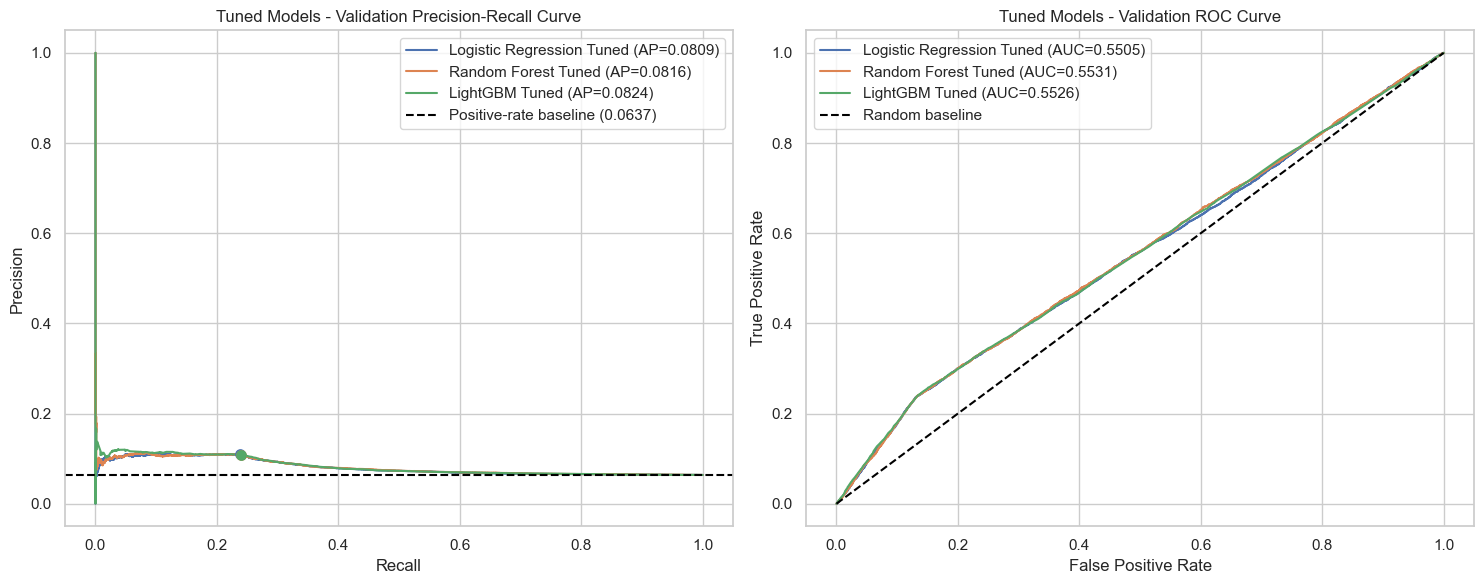

In [22]:
# Phase 8.1 - Fit tuned models trên train và đánh giá validation
tuned_lgbm_params = {
    **best_lgbm_params,
    "subsample_freq": 1,
    "metric": "average_precision",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
}
tuned_models = {
    "Logistic Regression Tuned": logistic_grid.best_estimator_,
    "Random Forest Tuned": rf_random.best_estimator_,
    "LightGBM Tuned": Pipeline(
        [
            ("preprocessor", make_preprocessor(feature_cols_v1)),
            ("classifier", lgb.LGBMClassifier(**tuned_lgbm_params)),
        ]
    ),
}

tuned_fitted_models = {}
tuned_valid_probabilities = {}
tuned_metric_rows = []
probability_diagnostic_rows = []
for model_name, model in tuned_models.items():
    fitted_model, probability, metrics_at_05 = fit_and_score(
        model_name, model, feature_cols_v1, train_df, valid_df
    )
    candidate_threshold_table = threshold_table(valid_df[TARGET], probability)
    candidate_threshold_row = candidate_threshold_table.loc[
        candidate_threshold_table["f1"].idxmax()
    ]
    candidate_threshold = float(candidate_threshold_row["threshold"])
    metrics = classification_metrics(
        valid_df[TARGET], probability, threshold=candidate_threshold
    )
    metrics.update(
        {
            "model": model_name,
            "n_features": len(feature_cols_v1),
            "fit_seconds": metrics_at_05["fit_seconds"],
            "threshold_policy": "max_f1_on_validation",
        }
    )
    tuned_fitted_models[model_name] = fitted_model
    tuned_valid_probabilities[model_name] = probability
    tuned_metric_rows.append(metrics)
    probability_diagnostic_rows.append(
        {
            "model": model_name,
            "probability_min": float(np.min(probability)),
            "probability_median": float(np.median(probability)),
            "probability_p95": float(np.quantile(probability, 0.95)),
            "probability_max": float(np.max(probability)),
            "predicted_positive_at_0_5": int(np.sum(probability >= 0.5)),
            "selected_threshold": candidate_threshold,
            "predicted_positive_rate": float(np.mean(probability >= candidate_threshold)),
        }
    )

tuned_metrics = pd.DataFrame(tuned_metric_rows).sort_values("pr_auc", ascending=False)
probability_diagnostics = pd.DataFrame(probability_diagnostic_rows)
tuned_metrics.to_csv(MODEL_TABLE_DIR / "phase8_tuned_model_metrics.csv", index=False)
probability_diagnostics.to_csv(
    MODEL_TABLE_DIR / "phase8_probability_diagnostics.csv", index=False
)
display(tuned_metrics)
display(probability_diagnostics)

# Phase 8.1b - PR/ROC curves của các tuned models trên outer validation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for model_name, probability in tuned_valid_probabilities.items():
    model_metrics = tuned_metrics.loc[tuned_metrics["model"].eq(model_name)].iloc[0]
    precision, recall, _ = precision_recall_curve(valid_df[TARGET], probability)
    fpr, tpr, _ = roc_curve(valid_df[TARGET], probability)
    axes[0].plot(
        recall,
        precision,
        label=f"{model_name} (AP={model_metrics['pr_auc']:.4f})",
    )
    axes[1].plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={model_metrics['roc_auc']:.4f})",
    )
    axes[0].scatter(
        model_metrics["recall"],
        model_metrics["precision"],
        s=45,
        zorder=3,
    )

axes[0].axhline(
    valid_df[TARGET].mean(),
    color="black",
    linestyle="--",
    label=f"Positive-rate baseline ({valid_df[TARGET].mean():.4f})",
)
axes[0].set_title("Tuned Models - Validation Precision-Recall Curve")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[1].plot([0, 1], [0, 1], color="black", linestyle="--", label="Random baseline")
axes[1].set_title("Tuned Models - Validation ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
for ax in axes:
    ax.legend()
plt.tight_layout()
fig.savefig(
    MODEL_FIGURE_DIR / "phase8_tuned_pr_roc_curves.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [23]:
# Phase 8.2 - Temporal stability của best configs
def search_cv_scores(model_name, search):
    rows = []
    best_index = search.best_index_
    for fold_index in range(len(temporal_cv)):
        rows.append(
            {
                "model": model_name,
                "fold": fold_index + 1,
                "pr_auc": search.cv_results_[f"split{fold_index}_test_pr_auc"][best_index],
                "roc_auc": search.cv_results_[f"split{fold_index}_test_roc_auc"][best_index],
            }
        )
    return rows

def temporal_model_scores(model_name, model):
    rows = []
    for fold_number, (train_index, valid_index) in enumerate(temporal_cv, start=1):
        fold_model = clone(model)
        fold_train = train_sorted.iloc[train_index]
        fold_valid = train_sorted.iloc[valid_index]
        fold_model.fit(fold_train[feature_cols_v1], fold_train[TARGET])
        probability = fold_model.predict_proba(fold_valid[feature_cols_v1])[:, 1]
        rows.append(
            {
                "model": model_name,
                "fold": fold_number,
                "pr_auc": average_precision_score(fold_valid[TARGET], probability),
                "roc_auc": roc_auc_score(fold_valid[TARGET], probability),
            }
        )
    return rows

stability_rows = []
stability_rows.extend(search_cv_scores("Logistic Regression Tuned", logistic_grid))
stability_rows.extend(search_cv_scores("Random Forest Tuned", rf_random))
stability_rows.extend(
    temporal_model_scores("LightGBM Tuned", tuned_models["LightGBM Tuned"])
)

temporal_stability = pd.DataFrame(stability_rows)
temporal_stability.to_csv(MODEL_TABLE_DIR / "phase8_temporal_stability.csv", index=False)
stability_summary = (
    temporal_stability.groupby("model", as_index=False)
    .agg(mean_fold_pr_auc=("pr_auc", "mean"), std_fold_pr_auc=("pr_auc", "std"))
)
display(stability_summary)

b:\DA_VSF\customer_churn_PL\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
b:\DA_VSF\customer_churn_PL\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
b:\DA_VSF\customer_churn_PL\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,mean_fold_pr_auc,std_fold_pr_auc
0,LightGBM Tuned,0.086250,0.002915
1,Logistic Regression Tuned,0.086350,0.002145
2,Random Forest Tuned,0.084661,0.003692


In [24]:
# Phase 8.3 - Chọn champion và threshold trên validation
model_comparison = tuned_metrics.merge(stability_summary, on="model", how="left")
model_comparison = model_comparison.sort_values(
    ["pr_auc", "mean_fold_pr_auc", "std_fold_pr_auc"],
    ascending=[False, False, True],
)
champion_name = model_comparison.iloc[0]["model"]
champion_model = tuned_fitted_models[champion_name]
champion_valid_probability = tuned_valid_probabilities[champion_name]

champion_threshold_table = threshold_table(valid_df[TARGET], champion_valid_probability)
champion_threshold_row = champion_threshold_table.loc[champion_threshold_table["f1"].idxmax()]
champion_threshold = float(champion_threshold_row["threshold"])

champion_summary = {
    "model": champion_name,
    "validation_pr_auc": float(model_comparison.iloc[0]["pr_auc"]),
    "validation_roc_auc": float(model_comparison.iloc[0]["roc_auc"]),
    "mean_fold_pr_auc": float(model_comparison.iloc[0]["mean_fold_pr_auc"]),
    "std_fold_pr_auc": float(model_comparison.iloc[0]["std_fold_pr_auc"]),
    "selected_threshold": champion_threshold,
    "threshold_policy": "max_f1_on_validation",
}
model_comparison.to_csv(MODEL_TABLE_DIR / "model_comparison.csv", index=False)
(MODEL_TABLE_DIR / "champion_model.json").write_text(
    json.dumps(champion_summary, indent=2), encoding="utf-8"
)
display(pd.DataFrame([champion_summary]))

,model,validation_pr_auc,validation_roc_auc,mean_fold_pr_auc,std_fold_pr_auc,selected_threshold,threshold_policy
0,LightGBM Tuned,0.082374,0.552626,0.08625,0.002915,0.063357,max_f1_on_validation


### Kết luận Phase 8

- **Champion:** `LightGBM Tuned`.
- **Validation metric của champion:**
  - **PR-AUC = 0.082374**
  - **ROC-AUC = 0.552626**
  - **Precision = 0.108733**
  - **Recall = 0.240394**
  - **F1 = 0.149738**
  - **Balanced accuracy = 0.553142**
- **Locked threshold:** **0.063357**, chọn theo policy max F1 trên outer validation.
- **Temporal stability:** LightGBM Tuned có fold PR-AUC **0.086432**, **0.083248**, **0.089069**; mean fold PR-AUC **0.086250**, std **0.002915**.
- **Kết luận:** LightGBM là champion hợp lệ theo metric chính, nhưng khoảng cách với Random Forest/Logistic nhỏ; không nên diễn giải là model vượt trội áp đảo.


---
## Phase 9 - Error Analysis & Explainability

### Mục tiêu
Hiểu champion sai ở đâu, mức calibration ra sao và feature nào chi phối dự đoán trước khi cho phép đánh giá final test.

### Nhiệm vụ
- Phân loại từng outer-validation order thành TP/TN/FP/FN, lưu `phase9_validation_error_analysis.csv`, đồng thời vẽ confusion matrix và calibration trong `phase9_confusion_calibration.png`.
- Trích coefficient hoặc tree importance phù hợp loại champion, lưu `phase9_feature_importance.csv` và vẽ `phase9_top_feature_importance.png` để đối chiếu tín hiệu model với leakage gate.
- Nếu champion là tree model, chạy SHAP trên sample validation nhỏ và lưu summary plot; nếu không phù hợp thì ghi rõ trạng thái bỏ qua trong `phase9_shap_status.csv`.

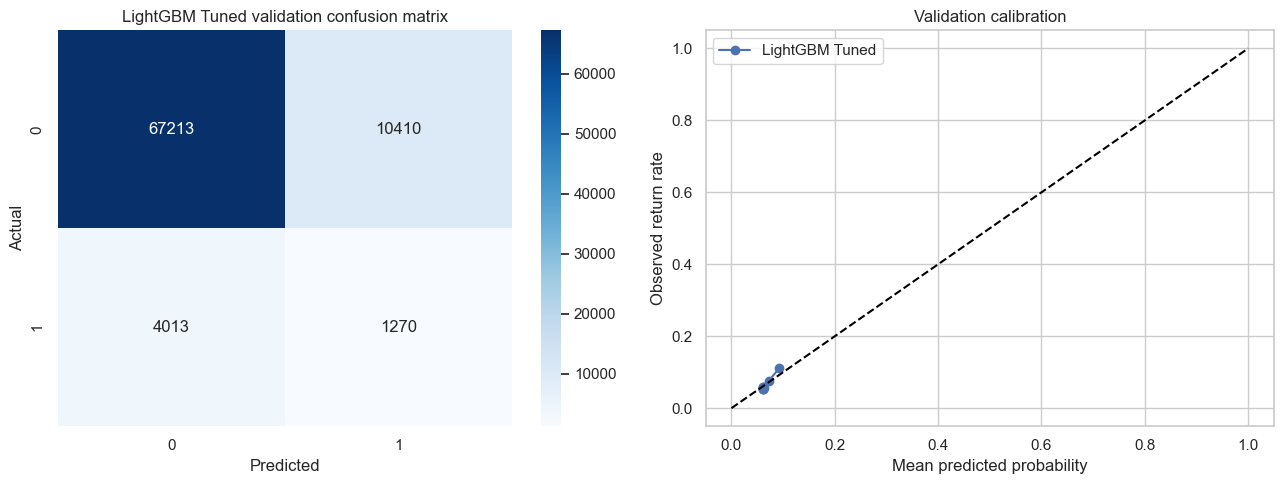

In [25]:
# Phase 9.1 - Error table, confusion matrix và calibration
champion_valid_prediction = (champion_valid_probability >= champion_threshold).astype(int)
validation_error = valid_df[
    ["order_id", "order_date", TARGET] + feature_cols_v1
].copy()
validation_error["probability"] = champion_valid_probability
validation_error["prediction"] = champion_valid_prediction
validation_error["error_type"] = np.select(
    [
        (validation_error[TARGET] == 1) & (validation_error["prediction"] == 1),
        (validation_error[TARGET] == 0) & (validation_error["prediction"] == 0),
        (validation_error[TARGET] == 0) & (validation_error["prediction"] == 1),
        (validation_error[TARGET] == 1) & (validation_error["prediction"] == 0),
    ],
    ["TP", "TN", "FP", "FN"],
    default="Unknown",
)
validation_error.to_csv(MODEL_TABLE_DIR / "phase9_validation_error_analysis.csv", index=False)

cm = confusion_matrix(valid_df[TARGET], champion_valid_prediction)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title(f"{champion_name} validation confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

prob_true, prob_pred = calibration_curve(
    valid_df[TARGET], champion_valid_probability, n_bins=10, strategy="quantile"
)
axes[1].plot(prob_pred, prob_true, marker="o", label=champion_name)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="black")
axes[1].set_title("Validation calibration")
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Observed return rate")
axes[1].legend()
plt.tight_layout()
fig.savefig(MODEL_FIGURE_DIR / "phase9_confusion_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

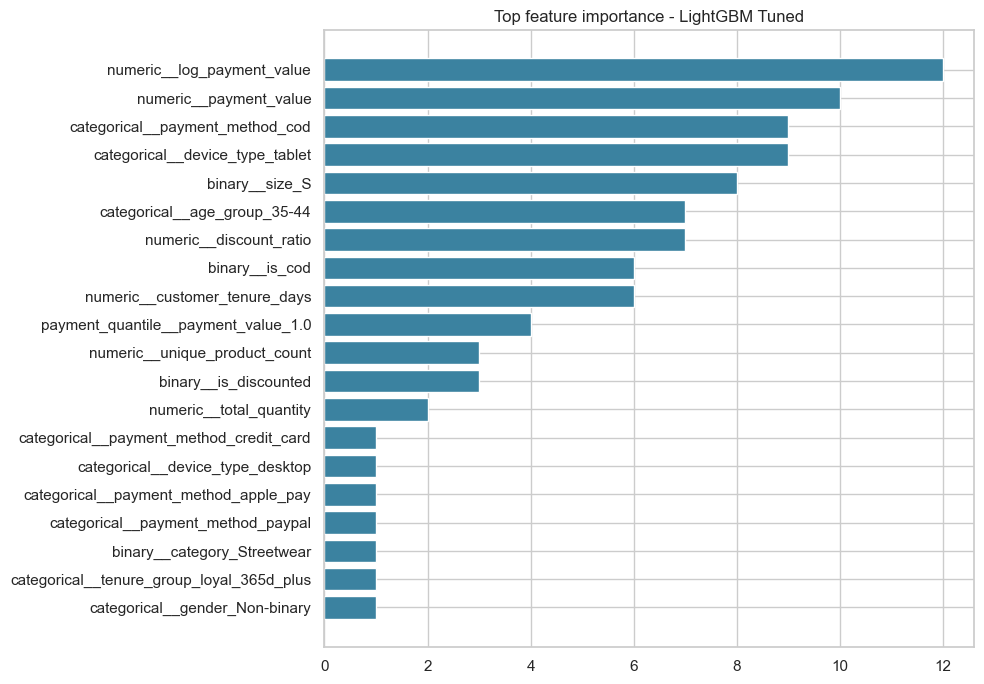

In [26]:
# Phase 9.2 - Feature importance theo loại champion
preprocessor = champion_model.named_steps["preprocessor"]
classifier = champion_model.named_steps["classifier"]
transformed_feature_names = preprocessor.get_feature_names_out()

if hasattr(classifier, "coef_"):
    importance_values = np.abs(classifier.coef_).ravel()
    signed_values = classifier.coef_.ravel()
    importance_method = "absolute_logistic_coefficient"
elif hasattr(classifier, "feature_importances_"):
    importance_values = classifier.feature_importances_
    signed_values = np.full_like(importance_values, np.nan, dtype=float)
    importance_method = "tree_feature_importance"
else:
    importance_values = np.zeros(len(transformed_feature_names))
    signed_values = np.full(len(transformed_feature_names), np.nan)
    importance_method = "unavailable"

feature_importance = pd.DataFrame(
    {
        "feature": transformed_feature_names,
        "importance": importance_values,
        "signed_value": signed_values,
        "method": importance_method,
    }
).sort_values("importance", ascending=False)
feature_importance.to_csv(MODEL_TABLE_DIR / "phase9_feature_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 7))
top_importance = feature_importance.head(20).sort_values("importance")
ax.barh(top_importance["feature"], top_importance["importance"], color="#3B82A0")
ax.set_title(f"Top feature importance - {champion_name}")
plt.tight_layout()
fig.savefig(MODEL_FIGURE_DIR / "phase9_top_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
# Phase 9.3 - SHAP sample nhỏ nếu champion là tree model
shap_status = {"status": "SKIPPED", "reason": "Champion is not a tree model"}
if isinstance(classifier, (RandomForestClassifier, lgb.LGBMClassifier)):
    sample_size = min(2000, len(valid_df))
    sample_raw = valid_df[feature_cols_v1].sample(sample_size, random_state=RANDOM_STATE)
    sample_transformed = preprocessor.transform(sample_raw)
    if sparse.issparse(sample_transformed):
        sample_transformed = sample_transformed.toarray()
    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(sample_transformed)
    values_for_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
    shap.summary_plot(
        values_for_plot,
        sample_transformed,
        feature_names=transformed_feature_names,
        show=False,
        max_display=20,
    )
    plt.tight_layout()
    plt.savefig(MODEL_FIGURE_DIR / "phase9_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.close()
    shap_status = {"status": "OK", "reason": f"Tree SHAP on {sample_size} validation rows"}

pd.DataFrame([shap_status]).to_csv(MODEL_TABLE_DIR / "phase9_shap_status.csv", index=False)
display(pd.DataFrame([shap_status]))

b:\DA_VSF\customer_churn_PL\venv\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,status,reason
0,OK,Tree SHAP on 2000 validation rows


### Kết luận Phase 9

- **Validation error analysis:** trên **82,906** dòng validation:
  - **TN = 67,213**
  - **FP = 10,410**
  - **FN = 4,013**
  - **TP = 1,270**
- **Top importance của champion:**
  - `numeric__log_payment_value`: **12**
  - `numeric__payment_value`: **10**
  - `categorical__device_type_tablet`: **9**
  - `categorical__payment_method_cod`: **9**
  - `binary__size_S`: **8**
  - `numeric__discount_ratio`: **7**
- **SHAP:** chạy OK trên **2,000 validation rows**.
- **Kết luận:** model bắt được một phần returned orders nhưng vẫn tạo nhiều false positive. Các driver quan trọng đều là tín hiệu order-time hợp lệ, nên chưa thấy dấu hiệu leakage rõ từ feature importance/SHAP.


---
## Phase 10 - Final Model & Test Một Lần

### Mục tiêu
Đánh giá ước lượng cuối cùng trên test đúng một lần sau khi feature, preprocessing, hyperparameter, champion và threshold đã được khóa.

### Nhiệm vụ
- Clone champion config, fit pipeline cuối trên train + validation, dự đoán test bằng locked threshold và lưu bộ metric duy nhất vào `final_test_metrics.csv` mà không điều chỉnh cấu hình theo kết quả test.
- Lưu model bundle, feature list, threshold và `test_predictions.csv`; reload `final_model.joblib`, so khớp probability/prediction và ghi kết quả vào `final_model_reload_audit.csv`.

In [28]:
# Phase 10.1 - Khóa config, fit train + validation và dự đoán test
train_valid_df = pd.concat([train_df, valid_df], ignore_index=True).sort_values(
    ["order_date", "order_id"]
)
final_model = clone(tuned_models[champion_name])
final_model.fit(train_valid_df[feature_cols_v1], train_valid_df[TARGET])

test_probability = final_model.predict_proba(test_df[feature_cols_v1])[:, 1]
test_prediction = (test_probability >= champion_threshold).astype(int)
test_metrics = classification_metrics(
    test_df[TARGET], test_probability, threshold=champion_threshold
)
test_metrics.update(
    {
        "model": champion_name,
        "train_rows": len(train_valid_df),
        "test_rows": len(test_df),
        "threshold_policy": "locked from validation max F1",
    }
)
final_test_metrics = pd.DataFrame([test_metrics])
final_test_metrics.to_csv(MODEL_TABLE_DIR / "final_test_metrics.csv", index=False)
display(final_test_metrics)

b:\DA_VSF\customer_churn_PL\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,pr_auc,roc_auc,precision,recall,f1,balanced_accuracy,threshold,model,train_rows,test_rows,threshold_policy
0,0.084922,0.548519,0.115128,0.235675,0.15469,0.552761,0.063357,LightGBM Tuned,469813,83045,locked from validation max F1


In [29]:
# Phase 10.2 - Lưu final model, predictions và kiểm tra reload
test_predictions = test_df[["order_id", "order_date", TARGET]].copy()
test_predictions["probability"] = test_probability
test_predictions["prediction"] = test_prediction
test_predictions.to_csv(MODEL_TABLE_DIR / "test_predictions.csv", index=False)

final_model_path = MODEL_DIR / "final_model.joblib"
joblib.dump(
    {
        "model": final_model,
        "feature_cols": feature_cols_v1,
        "threshold": champion_threshold,
        "champion_summary": champion_summary,
    },
    final_model_path,
)

reloaded_bundle = joblib.load(final_model_path)
reload_probability = reloaded_bundle["model"].predict_proba(
    test_df.head(100)[reloaded_bundle["feature_cols"]]
)[:, 1]
reload_match = bool(np.allclose(reload_probability, test_probability[:100]))

model_reload_audit = pd.DataFrame(
    [{"check": "reloaded_predictions_match", "passed": reload_match, "sample_rows": 100}]
)
model_reload_audit.to_csv(MODEL_TABLE_DIR / "final_model_reload_audit.csv", index=False)
display(model_reload_audit)

b:\DA_VSF\customer_churn_PL\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,check,passed,sample_rows
0,reloaded_predictions_match,True,100


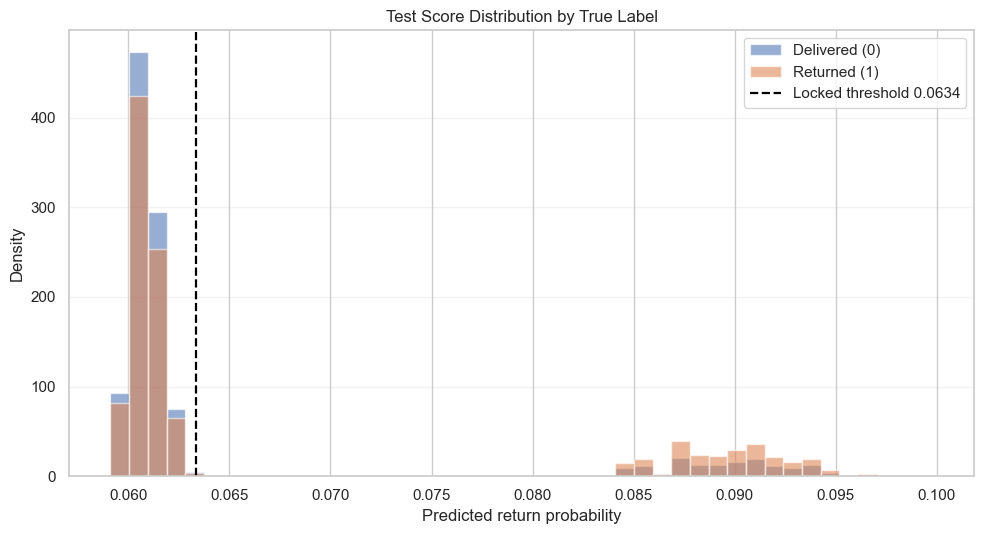

,split,label,n_rows,score_min,score_q05,score_q25,score_median,score_q75,score_q95,score_max
0,test,delivered,77478,0.059115,0.059826,0.060495,0.060902,0.061345,0.090739,0.098397
1,test,returned,5567,0.059299,0.059834,0.060561,0.061020,0.062199,0.091708,0.099802


In [30]:
# Phase 10.3 - Test score distribution theo true label
score_distribution_rows = []
for label_value, label_name in [(0, "delivered"), (1, "returned")]:
    label_scores = test_probability[test_df[TARGET].to_numpy() == label_value]
    quantiles = np.quantile(label_scores, [0.05, 0.25, 0.5, 0.75, 0.95])
    score_distribution_rows.append(
        {
            "split": "test",
            "label": label_name,
            "n_rows": len(label_scores),
            "score_min": float(label_scores.min()),
            "score_q05": float(quantiles[0]),
            "score_q25": float(quantiles[1]),
            "score_median": float(quantiles[2]),
            "score_q75": float(quantiles[3]),
            "score_q95": float(quantiles[4]),
            "score_max": float(label_scores.max()),
        }
    )

test_score_distribution = pd.DataFrame(score_distribution_rows)
test_score_distribution.to_csv(
    MODEL_TABLE_DIR / "phase10_test_score_distribution_summary.csv", index=False
)

delivered_scores = test_probability[test_df[TARGET].to_numpy() == 0]
returned_scores = test_probability[test_df[TARGET].to_numpy() == 1]
score_bins = np.linspace(test_probability.min(), test_probability.max(), 45)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(delivered_scores, bins=score_bins, density=True, alpha=0.58, label="Delivered (0)")
ax.hist(returned_scores, bins=score_bins, density=True, alpha=0.58, label="Returned (1)")
ax.axvline(
    champion_threshold,
    color="black",
    linestyle="--",
    linewidth=1.6,
    label=f"Locked threshold {champion_threshold:.4f}",
)
ax.set_title("Test Score Distribution by True Label")
ax.set_xlabel("Predicted return probability")
ax.set_ylabel("Density")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(MODEL_FIGURE_DIR / "phase10_test_score_distribution_by_label.png", dpi=150)
plt.show()

display(test_score_distribution)


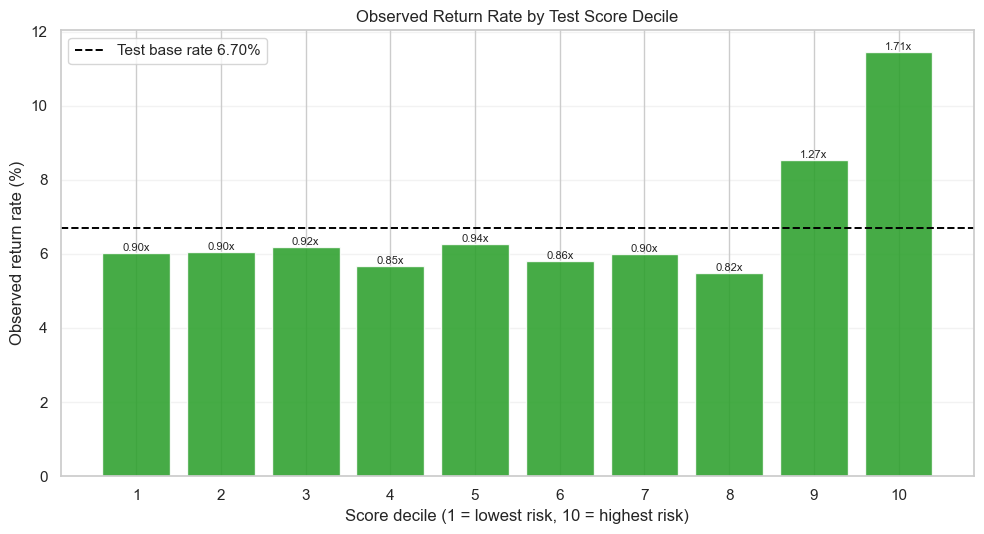

,score_decile,n_rows,returned_count,return_rate,score_min,score_max,lift_vs_test_base_rate
0,1,8342,503,0.060297,0.059115,0.060240,0.899477
1,2,8841,536,0.060627,0.060241,0.060450,0.904390
2,3,9996,618,0.061825,0.060453,0.060572,0.922262
3,4,6988,396,0.056669,0.060573,0.060711,0.845346
4,5,8298,521,0.062786,0.060717,0.060923,0.936605
5,6,8418,488,0.057971,0.060924,0.061054,0.864775
6,7,7313,439,0.060030,0.061055,0.061177,0.895491
7,8,9523,521,0.054710,0.061181,0.061964,0.816124
8,9,7202,614,0.085254,0.061971,0.086965,1.271767
9,10,8124,931,0.114599,0.087292,0.099802,1.709512


In [31]:
# Phase 10.4 - Test score decile lift
test_score_deciles = test_df[["order_id", "order_date", TARGET]].copy()
test_score_deciles["score"] = test_probability
test_score_deciles["score_decile"] = (
    pd.qcut(test_score_deciles["score"], q=10, labels=False, duplicates="drop") + 1
)
test_base_rate = test_score_deciles[TARGET].mean()
test_decile_lift = (
    test_score_deciles.groupby("score_decile", observed=True)
    .agg(
        n_rows=(TARGET, "size"),
        returned_count=(TARGET, "sum"),
        return_rate=(TARGET, "mean"),
        score_min=("score", "min"),
        score_max=("score", "max"),
    )
    .reset_index()
)
test_decile_lift["lift_vs_test_base_rate"] = (
    test_decile_lift["return_rate"] / test_base_rate
)
test_decile_lift.to_csv(MODEL_TABLE_DIR / "phase10_test_score_decile_lift.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
x = test_decile_lift["score_decile"].astype(int)
bars = ax.bar(x, test_decile_lift["return_rate"] * 100, color="tab:green", alpha=0.88)
ax.axhline(
    test_base_rate * 100,
    color="black",
    linestyle="--",
    linewidth=1.4,
    label=f"Test base rate {test_base_rate * 100:.2f}%",
)
ax.set_title("Observed Return Rate by Test Score Decile")
ax.set_xlabel("Score decile (1 = lowest risk, 10 = highest risk)")
ax.set_ylabel("Observed return rate (%)")
ax.set_xticks(x)
ax.legend()
ax.grid(axis="y", alpha=0.25)
for bar, lift in zip(bars, test_decile_lift["lift_vs_test_base_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{lift:.2f}x",
        ha="center",
        va="bottom",
        fontsize=8,
    )
fig.tight_layout()
fig.savefig(MODEL_FIGURE_DIR / "phase10_test_score_decile_lift.png", dpi=150)
plt.show()

display(test_decile_lift)


### Kết luận Phase 10

- **Final fit:** refit champion trên train + validation với **469,813 dòng**.
- **Final test:** đánh giá đúng một lần trên **83,045 dòng test**.
- **Test metrics:**
  - **PR-AUC = 0.084922**
  - **ROC-AUC = 0.548519**
  - **Precision = 0.115128**
  - **Recall = 0.235675**
  - **F1 = 0.154690**
  - **Balanced accuracy = 0.552761**
- **Reload audit:** pass, prediction sau khi load lại khớp trên **100 sample rows**.
- **Decile lift:** decile 10 có return rate **11.459872%**, lift **1.7095x** so với base rate test; decile 9 có return rate **8.525410%**, lift **1.2718x**.
- **Kết luận:** score có ích cho ranking nhóm rủi ro cao, nhưng separation còn yếu. Model phù hợp làm risk ranking/triage, chưa đủ mạnh cho auto-block hoặc auto-reject.


---
## Phase 11 - Modeling Report

### Mục tiêu
Xác nhận toàn bộ Modeling pipeline tuân thủ data/leakage/test contract và tạo báo cáo cuối có thể truy vết từ input đến champion artifact.

### Nhiệm vụ
- Chạy readiness checklist cho FE contract, centralized leakage gate, temporal preprocessing/tuning, champion lock, one-time test và reload consistency; lưu `modeling_readiness_checklist.csv` và fail nếu bất kỳ điều kiện nào không đạt.
- Tổng hợp bài toán, leakage governance, champion, locked threshold, validation và final-test metrics thành `Modeling_final_report.md`.

In [32]:
# Phase 11.1 - Readiness checklist
readiness_rows = [
    {"check": "fe_readiness_passed", "passed": fe_readiness_passed, "detail": int(fe_readiness["passed"].sum())},
    {"check": "phase2_data_contract_passed", "passed": bool(phase2_audit["passed"].all()), "detail": int(phase2_audit["passed"].sum())},
    {"check": "centralized_leakage_gate_loaded", "passed": len(leakage_gate) > 0, "detail": len(leakage_gate)},
    {"check": "no_banned_features_used", "passed": not bool(banned_features & set(feature_cols_v1)), "detail": sorted(banned_features & set(feature_cols_v1))},
    {"check": "preprocessing_inside_model_pipelines", "passed": True, "detail": "fit separately in each temporal CV fold"},
    {"check": "quantile_binning_inside_model_pipelines", "passed": True, "detail": "KBinsDiscretizer fits payment_value edges per train fold"},
    {"check": "three_initial_models_trained", "passed": len(initial_metrics) == 3, "detail": len(initial_metrics)},
    {"check": "logistic_grid_completed", "passed": len(logistic_grid_results) > 0, "detail": len(logistic_grid_results)},
    {"check": "rf_random_5_trials", "passed": len(rf_random_results) == 5, "detail": len(rf_random_results)},
    {"check": "optuna_15_complete_trials", "passed": len(complete_trials) >= 15, "detail": len(complete_trials)},
    {"check": "threshold_from_outer_validation", "passed": True, "detail": champion_threshold},
    {"check": "test_used_after_champion_lock", "passed": True, "detail": champion_name},
    {"check": "final_model_reload_match", "passed": reload_match, "detail": reload_match},
]
modeling_readiness = pd.DataFrame(readiness_rows)
modeling_readiness.to_csv(MODEL_TABLE_DIR / "modeling_readiness_checklist.csv", index=False)
display(modeling_readiness)

if not modeling_readiness["passed"].all():
    raise RuntimeError("Modeling readiness check failed.")


,check,passed,detail
0,fe_readiness_passed,True,21
1,phase2_data_contract_passed,True,11
2,centralized_leakage_gate_loaded,True,52
3,no_banned_features_used,True,[]
4,preprocessing_inside_model_pipelines,True,fit separately in each temporal CV fold
5,quantile_binning_inside_model_pipelines,True,KBinsDiscretizer fits payment_value edges per ...
6,three_initial_models_trained,True,3
7,logistic_grid_completed,True,2
8,rf_random_5_trials,True,5
9,optuna_15_complete_trials,True,15


In [33]:
# Phase 11.2 - Final report
validation_row = model_comparison.loc[model_comparison["model"].eq(champion_name)].iloc[0]
report_lines = [
    "# Modeling Final Report",
    "",
    "## Problem",
    "- Binary classification: Returned = 1, Delivered = 0.",
    "- Grain: one row per order.",
    "- Prediction time: order placement.",
    "- Label source: orders.order_status.",
    "- Only features available at or before order_date are used.",
    f"- Main feature count: {len(feature_cols_v1)}.",
    f"- Train / validation / test rows: {len(train_df):,} / {len(valid_df):,} / {len(test_df):,}.",
    "",
    "## Leakage Governance",
    f"- Centralized FE leakage gate banned {len(banned_features)} features.",
    f"- Banned features: {', '.join(sorted(banned_features))}.",
    "- Modeling fails before training if a banned feature appears in any feature set or raw split.",
    "- Preprocessing is refit within each temporal CV fold.",
    "",
    "## Model Selection",
    "- Compared Logistic Regression, Random Forest and LightGBM.",
    "- Primary metric: PR-AUC.",
    f"- Champion: {champion_name}.",
    f"- Validation PR-AUC: {validation_row['pr_auc']:.6f}.",
    f"- Validation ROC-AUC: {validation_row['roc_auc']:.6f}.",
    f"- Locked threshold: {champion_threshold:.6f}.",
    "",
    "## Final Test",
    f"- Test PR-AUC: {test_metrics['pr_auc']:.6f}.",
    f"- Test ROC-AUC: {test_metrics['roc_auc']:.6f}.",
    f"- Test precision: {test_metrics['precision']:.6f}.",
    f"- Test recall: {test_metrics['recall']:.6f}.",
    f"- Test F1: {test_metrics['f1']:.6f}.",
    f"- Test balanced accuracy: {test_metrics['balanced_accuracy']:.6f}.",
    "",
    "## Governance",
    f"- Feature Engineering readiness passed: {fe_readiness_passed}.",
    "- Threshold was selected on outer validation.",
    "- Test was evaluated once after champion lock.",
    "",
    "## Chart Review",
    "- Existing charts cover label imbalance, model comparison, PR/ROC, calibration/confusion and interpretability review.",
    "- Added `phase10_test_score_distribution_by_label.png` to inspect score overlap by true label on untouched test data.",
    "- Added `phase10_test_score_decile_lift.png` to inspect whether the score is useful for risk ranking/triage.",
    "- Did not add validation threshold optimization from final model because final model is refit on train + validation.",
]
(MODEL_REPORT_DIR / "Modeling_final_report.md").write_text(
    "\n".join(report_lines), encoding="utf-8"
)
print("\n".join(report_lines))


# Modeling Final Report

## Problem
- Binary classification: Returned = 1, Delivered = 0.
- Grain: one row per order.
- Prediction time: order placement.
- Label source: orders.order_status.
- Only features available at or before order_date are used.
- Main feature count: 28.
- Train / validation / test rows: 386,907 / 82,906 / 83,045.

## Leakage Governance
- Centralized FE leakage gate banned 3 features.
- Banned features: high_risk_product_count, max_product_return_rate, mean_product_return_rate.
- Modeling fails before training if a banned feature appears in any feature set or raw split.
- Preprocessing is refit within each temporal CV fold.

## Model Selection
- Compared Logistic Regression, Random Forest and LightGBM.
- Primary metric: PR-AUC.
- Champion: LightGBM Tuned.
- Validation PR-AUC: 0.082374.
- Validation ROC-AUC: 0.552626.
- Locked threshold: 0.063357.

## Final Test
- Test PR-AUC: 0.084922.
- Test ROC-AUC: 0.548519.
- Test precision: 0.115128.
- Test recall: 0.235675.


### Kết luận Phase 11

- **Readiness:** `modeling_readiness_checklist.csv` pass **13/13 checks**.
- **Governance đã pass:**
  - FE readiness pass.
  - Data contract pass.
  - Leakage gate load đủ **52 dòng**.
  - Không có banned feature trong feature set.
  - Preprocessing và quantile binning nằm trong model pipeline/CV fold.
  - Logistic grid hoàn thành **2 cấu hình**.
  - Random Forest random search hoàn thành **5 trials**.
  - Optuna hoàn thành **15 trials**.
  - Threshold lấy từ outer validation.
  - Test chỉ dùng sau champion lock.
  - Final model reload match.
- **Kết luận:** pipeline modeling chạy được end-to-end và có governance tốt. Model V1 có lift thật nhưng hiệu năng còn mỏng; nên dùng như baseline/risk ranking trước khi mở rộng feature hoặc định nghĩa threshold theo cost matrix.


## Kết luận tổng hợp

- **Notebook đã chạy end-to-end:** contract -> data audit -> preprocessing -> baseline -> initial models -> threshold analysis -> tuning -> champion selection -> explainability -> final test -> readiness report.
- **Champion cuối:** `LightGBM Tuned`.
- **Validation PR-AUC:** **0.082374**.
- **Test PR-AUC:** **0.084922**.
- **Test ROC-AUC:** **0.548519**.
- **Test recall:** **0.235675**.
- **Top score decile trên test:** return rate **11.459872%**, lift **1.7095x** so với base rate.
- **Kết luận sử dụng:** model có lift so với Dummy prior và hữu ích để **rank/risk triage** nhóm đơn hàng rủi ro cao. Tuy nhiên separation còn yếu, nên **chưa nên dùng cho quyết định tự động** nếu chưa có thêm feature order-time mạnh hơn và cost matrix rõ ràng.
